In [119]:
import os
import cv2
import sklearn
import pandas as pd
import numpy as np,random
import seaborn as sn
import tensorflow as tf
from sklearn.svm import SVC
from keras.optimizers import Adam
from sklearn.utils import shuffle
from sklearn.svm import LinearSVC
from tensorflow import keras
import matplotlib.pyplot as plt
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
from tensorflow.keras.models import Sequential
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.layers import BatchNormalization,MaxPooling2D,Conv2D,Flatten,Dense,Dropout


In [120]:
path_of_dir=os.listdir('../brain tumor/')
classes_in_dir={'Brain Tumor':1,'Healthy':0}

classes_in_dir

{'Brain Tumor': 1, 'Healthy': 0}

In [121]:
def safe_augment(img):
    h, w = img.shape[:2]

    # 1. Fixed rotation (e.g., 5 degrees)
    angle = 5
    M_rot = cv2.getRotationMatrix2D((w//2, h//2), angle, 1.0)
    img = cv2.warpAffine(img, M_rot, (w, h), borderMode=cv2.BORDER_REFLECT)

    # 2. Fixed zoom (e.g., 1.05x)
    zf = 1.05
    zh, zw = int(h*zf), int(w*zf)
    img = cv2.resize(img, (zw, zh))
    start_y = max((zh - h)//2, 0)
    start_x = max((zw - w)//2, 0)
    img = img[start_y:start_y+h, start_x:start_x+w]

    # 3. Fixed brightness (+10)
    beta = 10
    img = cv2.convertScaleAbs(img, alpha=1.0, beta=beta)

    # 4. Fixed gamma (1.05)
    gamma = 1.05
    img = np.power(img / 255.0, gamma) * 255
    img = img.astype(np.uint8)

    # 5. Always apply Gaussian blur
    img = cv2.GaussianBlur(img, (3, 3), 0)

    # 6. Always flip horizontally
    img = cv2.flip(img, 1)

    return img



X, Y = [], []

for i in classes_in_dir:
    path = '../brain tumor/' + i
    for j in os.listdir(path):
        pic = cv2.imread(path + '/' + j, cv2.IMREAD_GRAYSCALE)  # Force grayscale
        pic = cv2.resize(pic, (200, 200))                       # Force size
        # pic = safe_augment(pic)
        pic = np.array(pic, dtype='float32')
        if pic.shape != (200, 200):
            pic = cv2.resize(pic, (200, 200))

        X.append(pic)
        Y.append(classes_in_dir[i])

       


In [122]:
x = np.array(X).reshape(-1, 200, 200, 1) / 255  # normalize
y = np.array(Y)

In [123]:
pd.Series(y).value_counts()

1    3000
0    3000
Name: count, dtype: int64

In [124]:
y.shape

(6000,)

In [125]:
x.shape

(6000, 200, 200, 1)

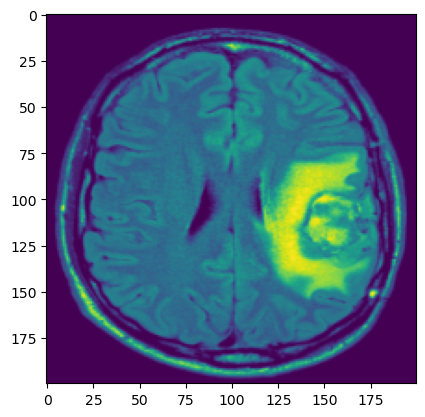

In [126]:
plt.imshow(x[1])


In [127]:
x.shape

(6000, 200, 200, 1)

In [128]:
x, y = shuffle(x, y, random_state=10)

In [129]:
x_train3D,x_test3D,y_train3D,y_test3D=train_test_split(x ,y,random_state=42,test_size=0.20)

Text(0.5, 0, '1')

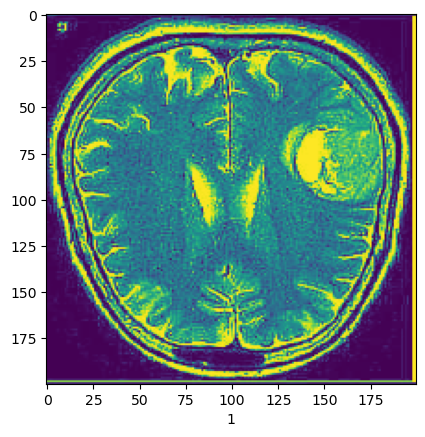

In [130]:
plt.imshow(x_test3D[5])
plt.xlabel(y_test3D[5])


In [131]:
x_train3D.shape

(4800, 200, 200, 1)

#CNN MODEL

In [132]:
cnn=Sequential([keras.layers.Input(shape=(200,200,1)),
Conv2D(filters=32, kernel_size=(3, 3), activation='relu'), # convolutional layer
BatchNormalization(),
MaxPooling2D(), # pooling layer

Conv2D(filters=64, kernel_size=(3, 3), activation='relu'), # convolutional layer
BatchNormalization(),
MaxPooling2D(), # pooling layer

Flatten(),
Dense(1, activation='sigmoid')

])

cnn.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_2 (Conv2D)           (None, 198, 198, 32)      320       
                                                                 
 batch_normalization_2 (Batc  (None, 198, 198, 32)     128       
 hNormalization)                                                 
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 99, 99, 32)       0         
 2D)                                                             
                                                                 
 conv2d_3 (Conv2D)           (None, 97, 97, 64)        18496     
                                                                 
 batch_normalization_3 (Batc  (None, 97, 97, 64)       256       
 hNormalization)                                                 
                                                      

In [133]:
cnn.compile(optimizer=Adam(learning_rate=1e-4),loss='binary_crossentropy', metrics=['accuracy'])

In [134]:
cnn.fit(x_train3D,y_train3D,validation_data=(x_test3D,y_test3D), epochs=3, batch_size=16)

Epoch 1/3
300/300 [==============================] - 90s 297ms/step - loss: 0.4988 - accuracy: 0.8302 - val_loss: 0.4200 - val_accuracy: 0.8267
Epoch 2/3
300/300 [==============================] - 88s 295ms/step - loss: 0.1367 - accuracy: 0.9531 - val_loss: 0.2281 - val_accuracy: 0.9200
Epoch 3/3
300/300 [==============================] - 89s 295ms/step - loss: 0.0625 - accuracy: 0.9783 - val_loss: 0.1324 - val_accuracy: 0.9600


In [135]:
test_loss,test_acc=cnn.evaluate(x_test3D,y_test3D,verbose=2)

38/38 - 6s - loss: 0.1324 - accuracy: 0.9600 - 6s/epoch - 148ms/step


In [136]:
pred1=(cnn.predict(x_test3D)>0.5).astype('int').flatten()

38/38 [==============================] - 6s 142ms/step


In [137]:
print(pred1[0:20])

[0 0 1 0 0 1 1 0 0 0 1 1 1 1 0 1 0 1 0 0]


In [138]:
accuracy_score(y_test3D,pred1)

0.96

In [139]:
conf_mat= confusion_matrix(y_test3D,pred1)
print(classification_report(y_test3D,pred1))


              precision    recall  f1-score   support

           0       0.96      0.96      0.96       598
           1       0.96      0.96      0.96       602

    accuracy                           0.96      1200
   macro avg       0.96      0.96      0.96      1200
weighted avg       0.96      0.96      0.96      1200



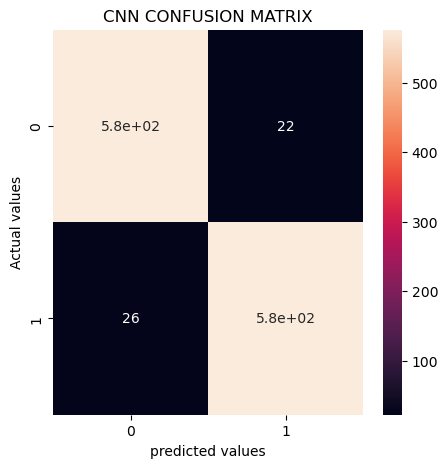

In [140]:
plt.figure(figsize=(5,5))
sn.heatmap(conf_mat,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("CNN CONFUSION MATRIX")
plt.show()

#Random forest

In [141]:
x_updated=x.reshape(len(x),-1)

In [142]:
x_updated.shape

(6000, 40000)

In [143]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_updated)

In [144]:
x_train2D,x_test2D,y_train2D,y_test2D=train_test_split(x_scaled,y,random_state=42,test_size=0.20)

In [145]:
x_train2D.shape

(4800, 40000)

In [146]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,      
    min_samples_split=2, 
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)


rf.fit(x_train2D, y_train2D)



RandomForestClassifier(max_depth=20, n_estimators=200, n_jobs=-1,
                       random_state=42)

In [147]:
pred2=rf.predict(x_test2D)

In [148]:
accuracy_score(y_test2D,pred2)

0.9516666666666667

In [149]:

conf_mat2=confusion_matrix(y_test2D,pred2)


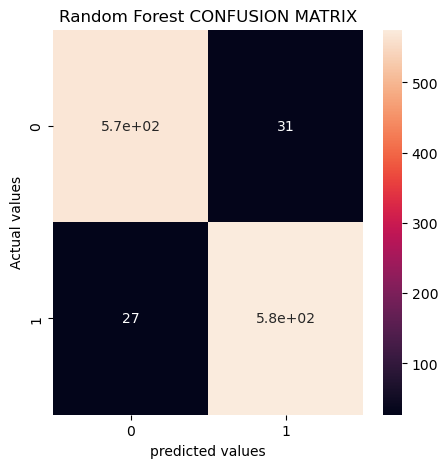

In [150]:
plt.figure(figsize=(5,5))
sn.heatmap(conf_mat2,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("Random Forest CONFUSION MATRIX")
plt.show()

#SVM

In [151]:
svm_pipeline = Pipeline([
    ('pca', PCA(n_components=1000)),        # reduce to 500 features
    ('svm', LinearSVC(C=1.0, max_iter=2000, tol=1e-3))  # fewer iterations needed
])

svm_pipeline.fit(x_train2D, y_train2D)
pred3 =svm_pipeline.predict(x_test2D)



In [152]:
accuracy_score(y_test2D,pred3)

0.905

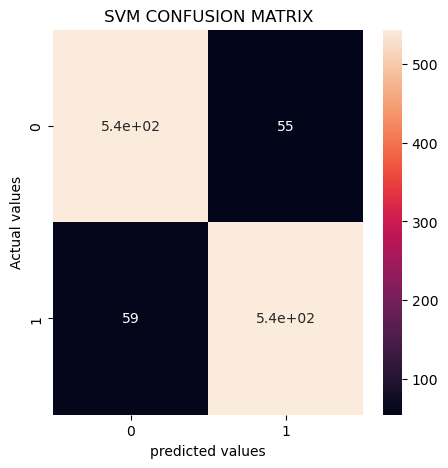

In [153]:
conf_mat3=confusion_matrix(y_test2D,pred3)
plt.figure(figsize=(5,5))
sn.heatmap(conf_mat3,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("SVM CONFUSION MATRIX")
plt.show()

#KNN

In [154]:
knn =KNeighborsClassifier(n_neighbors=3, weights='distance',metric= 'manhattan')
knn.fit(x_train2D, y_train2D) 

KNeighborsClassifier(metric='manhattan', n_neighbors=3, weights='distance')

In [155]:
pred4=knn.predict(x_test2D)

In [156]:
print("Accuracy:", accuracy_score(y_test2D, pred4))

Accuracy: 0.9633333333333334


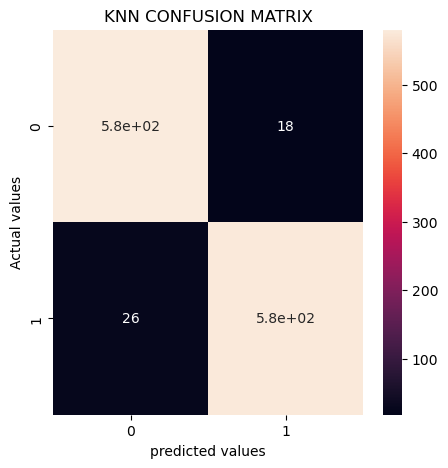

In [157]:
conf_mat4=confusion_matrix(y_test2D,pred4)
plt.figure(figsize=(5,5))
sn.heatmap(conf_mat4,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("KNN CONFUSION MATRIX")
plt.show()

#Logistic Regression

In [158]:
LR = LogisticRegression()
LR.fit(x_train2D, y_train2D)

LogisticRegression()

In [159]:
LR = LogisticRegression(
    C=0.0054,
    class_weight="balanced",
    penalty='l2',
    solver='liblinear',
    max_iter=100
)
LR.fit(x_train2D, y_train2D)

LogisticRegression(C=0.0054, class_weight='balanced', solver='liblinear')

In [160]:
print("Train:", LR.score(x_train2D, y_train2D))
print("Validation:", LR.score(x_test2D, y_test2D))

Train: 0.9997916666666666
Validation: 0.9366666666666666


In [161]:
pred5 = LR.predict(x_test2D)

print("Accuracy:", accuracy_score(y_test2D, pred5))
print("\nClassification Report:\n", classification_report(y_test2D, pred5))

Accuracy: 0.9366666666666666

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.93      0.94       598
           1       0.93      0.95      0.94       602

    accuracy                           0.94      1200
   macro avg       0.94      0.94      0.94      1200
weighted avg       0.94      0.94      0.94      1200



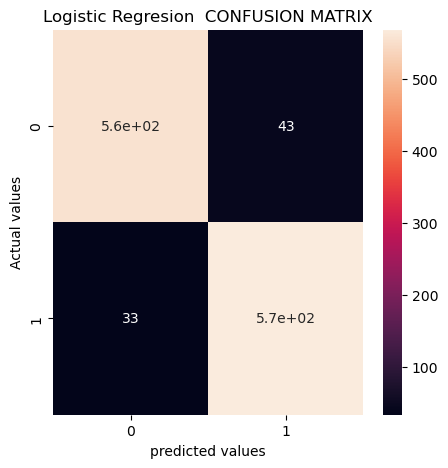

In [162]:
conf_mat5= confusion_matrix(y_test2D,pred5)
plt.figure(figsize=(5,5))
sn.heatmap(conf_mat5,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("Logistic Regresion  CONFUSION MATRIX")
plt.show()

# ALL PREDICTED VALUES

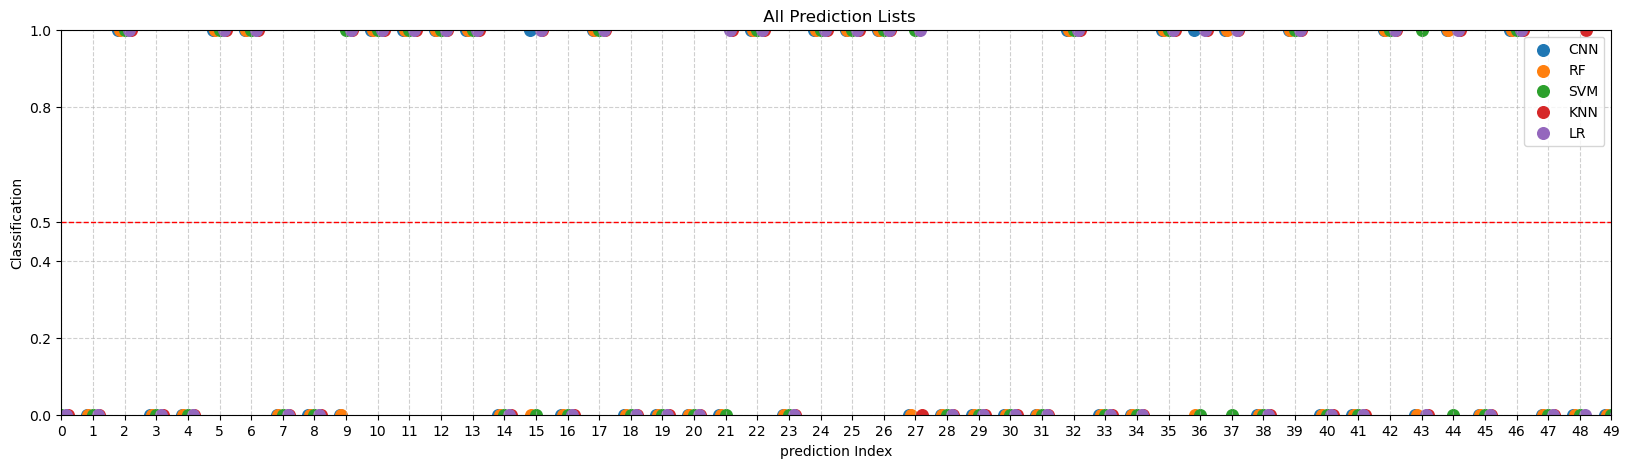

In [163]:
sze=np.arange(len(pred1))
plt.figure(figsize=(20,5))
plt.scatter(sze - 0.2, pred1, label='CNN', alpha=1, s=70)
plt.scatter(sze - 0.15, pred2, label='RF', alpha=1, s=70)
plt.scatter(sze, pred3, label='SVM', alpha=1, s=70)
plt.scatter(sze + 0.2, pred4, label='KNN', alpha=1, s=70)
plt.scatter(sze + 0.15 , pred5, label='LR', alpha=1, s=70)

plt.axhline(y=0.5, color='red', linestyle='--', linewidth=1)

plt.ylim(0,1)
plt.xlim(0,10)
plt.xticks(range(0,50))
plt.yticks([0, 0.2,0.4,0.5,0.8,1])
plt.xlabel('prediction Index')
plt.ylabel('Classification')
plt.title(' All Prediction Lists')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()


In [164]:
pp1=(cnn.predict(x_test3D)>0.5).astype('int').flatten()
pp2=rf.predict(x_test2D)
pp3=svm_pipeline.predict(x_test2D)
pp4=knn.predict(x_test2D)
pp5=LR.predict(x_test2D)

38/38 [==============================] - 6s 146ms/step


In [165]:
print(pp1[0:2])

[0 0]


In [166]:
total_prediction=[]
for i in range(len(pp3)):
    totaladd=pp1[i]+pp2[i]+pp3[i]+pp4[i]+pp5[i]
    total_prediction.append(totaladd)


In [167]:
Ensemble_prediction = [1 if val >= 3 else 0 for val in total_prediction]
print(Ensemble_prediction[:6])

[0, 0, 1, 0, 0, 1]


In [168]:
print(y_test2D[0:6])

[0 0 1 0 0 1]


In [169]:
print(pred1[0:6])

[0 0 1 0 0 1]


In [170]:
print(pred2[0:6])

[0 0 1 0 0 1]


In [171]:
print(pred3[0:6])

[0 0 1 0 0 1]


In [172]:
print(pred4[0:6])

[0 0 1 0 0 1]


In [173]:
print(pred5[0:6])

[0 0 1 0 0 1]


In [174]:
g=np.where(y_test2D != Ensemble_prediction)[0]
print(g)

[   9   36   48  160  164  179  180  232  246  270  332  368  377  418
  419  489  496  500  502  510  639  690  767  783  793  796  856  942
  949  974  976  983  989 1008 1058 1071 1078 1091 1093 1114]


In [175]:
print("Accuracy:", accuracy_score(y_test2D, Ensemble_prediction))
print("\nClassification Report:\n", classification_report(y_test2D, Ensemble_prediction))

Accuracy: 0.9666666666666667

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.96      0.97       598
           1       0.96      0.97      0.97       602

    accuracy                           0.97      1200
   macro avg       0.97      0.97      0.97      1200
weighted avg       0.97      0.97      0.97      1200



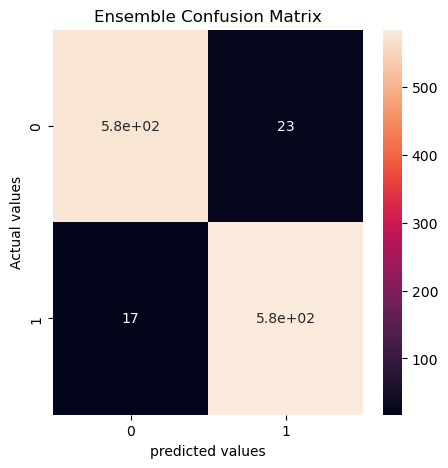

In [176]:
ensemble_confusion_matrix= confusion_matrix(y_test2D,Ensemble_prediction)
plt.figure(figsize=(5,5))
sn.heatmap(ensemble_confusion_matrix,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("Ensemble Confusion Matrix")
plt.show()

In [177]:
x_pred, y_pred = [], []
img_path = r"D:\My Final Work\external_pic" 
for j in os.listdir(img_path):
        pic = cv2.imread(img_path + '/' + j, 0)  
        pic = cv2.resize(pic, (200, 200))                       
        pic = np.array(pic)
        x_pred.append(pic)
        y_pred.append(j)


(-0.5, 199.5, 199.5, -0.5)

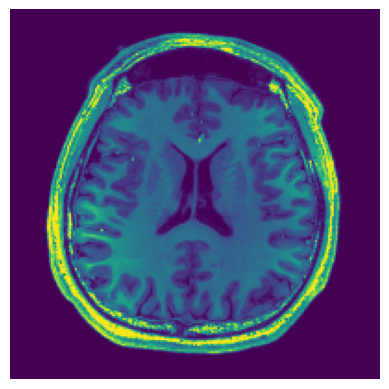

In [178]:
plt.imshow(x_pred[1])
plt.axis('off')

In [189]:
img_path = r"D:\My Final Work\external_pic"
images_cnn = []   
images_flat = []  
filenames = []

for file in os.listdir(img_path):
    path = os.path.join(img_path, file)
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (200, 200))
    images_cnn.append(img)
    images_flat.append(img.reshape(-1))
    filenames.append(file)
images_cnn = np.array(images_cnn).reshape(-1, 200, 200, 1) / 255.0
images_flat = scaler.fit_transform(np.array(images_flat))  # normalize features
pred_cnn = (cnn.predict(images_cnn) > 0.5).astype(int).flatten()
pred_rf  = rf.predict(images_flat)
pred_svm = svm_pipeline.predict(images_flat)
pred_lr  = LR.predict(images_flat)
pred_knn = knn.predict(images_flat)
results = []
for i, name in enumerate(filenames):
    votes = pred_cnn[i] + pred_rf[i] + pred_svm[i] + pred_lr[i] + pred_knn[i]
    if votes >= 3:
        label = "Tumor"
    else:
        label = "No Tumor"

    results.append((name, label))
print("\n Total Predictions:")
for file, label in results:
   print(file + " -------> " + label)



1/1 [==============================] - 0s 61ms/step

 Total Predictions:
h1.jpeg -------> No Tumor
h2.jpg -------> No Tumor
h3.jpeg -------> No Tumor
h4.jpeg -------> Tumor
h5.jpeg -------> No Tumor
h6.jpg -------> No Tumor
t1.jpeg -------> No Tumor
t4.jpeg -------> No Tumor
t5.png -------> No Tumor
t6.jpeg -------> Tumor


In [180]:
img_path2 = r"D:\My Final Work\external_pic/t1.jpeg" 
pic1 = cv2.imread(img_path2,0)  
pic1= cv2.resize(pic1, (200, 200))


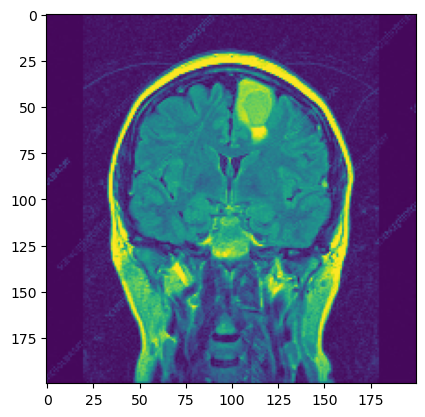

In [181]:
plt.imshow(pic1)

In [182]:
cnnpred1 = pic1.reshape(1, 200, 200, 1)
cnnpred = cnnpred1 / 255.0

In [183]:
cnnpred.shape

(1, 200, 200, 1)

In [184]:
p11 = (cnn.predict(cnnpred) > 0.5).astype('int').flatten()

1/1 [==============================] - 0s 19ms/step


In [185]:
print(p11)

[0]


In [186]:
p_2D=cnnpred.reshape(1, -1)
p_2D.shape

(1, 40000)

In [187]:
x_scaled = scaler.fit_transform(p_2D)
p22=rf.predict(x_scaled)
p33=svm_pipeline.predict(x_scaled)
p44=LR.predict(x_scaled)
p55 = knn.predict(x_scaled)
print('CNN =',p11)
print('RF =',p22)
print('SVM =',p33)
print('LR =',p44)
print('KNN =',p55)

if(p11+p22+p33+p44+p55 >= 3):
    print(" \n Tumor")
elif (p11+p22+p33+p44+p55 < 3):
    print( "\n No Tumor")

CNN = [0]
RF = [0]
SVM = [1]
LR = [0]
KNN = [0]

 No Tumor
